vlm=2: entries = 156757.0
vlm=3: entries = 88299.0
vlm=6: entries = 325866.0


Info in <TCanvas::Print>: png file de_vlm_plot.png has been created


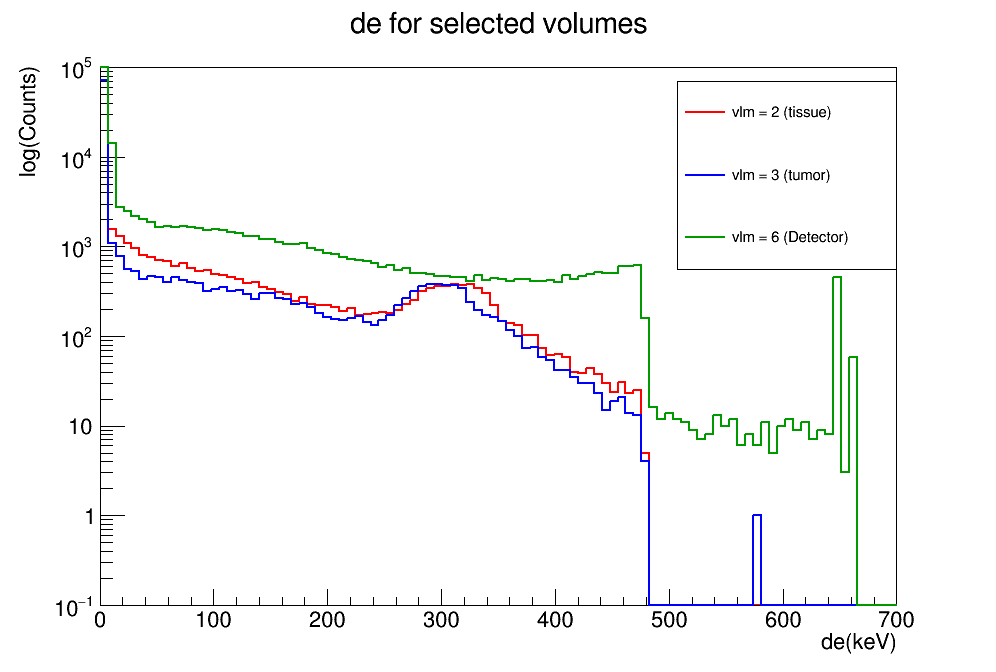

In [1]:
import ROOT
from IPython.display import Image, display

%jsroot on

f = ROOT.TFile.Open("tumor.root")
t = f.Get("t")

c = ROOT.TCanvas("c", "de for selected volumes", 1000, 700)
c.cd()
c.SetLogy()

legend = ROOT.TLegend(0.68, 0.60, 0.90, 0.88)
legend.SetBorderSize(1)
legend.SetFillStyle(0)
legend.SetTextSize(0.025)

colors = [ROOT.kRed, ROOT.kBlue, ROOT.kGreen+2]

names = {
    2: "tissue",
    3: "tumor",
    6: "Detector",
}

selected_vlm = [2, 3, 6]

hist_list = []
first = True

for i, vlm in enumerate(selected_vlm):
    hname = f"h_vlm_{vlm}"   # very important

    old = ROOT.gROOT.FindObject(hname)
    if old:
        old.Delete()

    h = ROOT.TH1F(hname, "de for selected volumes;de(keV);log(Counts)", 100, 0, 700)
    t.Draw(f"de>>{hname}", f"vlm=={vlm}", "goff")

    print(f"vlm={vlm}: entries =", h.GetEntries())

    if h.GetEntries() == 0:
        continue

    h.SetLineColor(colors[i])
    h.SetLineWidth(2)
    h.SetStats(0)

    if first:
        h.SetMinimum(0.1)
        h.SetMaximum(1e5)
        h.Draw("hist")
        first = False
    else:
        h.Draw("hist same")

    label = f"vlm = {vlm}"
    if vlm in names:
        label += f" ({names[vlm]})"

    legend.AddEntry(h, label, "l")
    hist_list.append(h)

legend.Draw()
c.Modified()
c.Update()

c.SaveAs("de_vlm_plot.png")
display(Image(filename="de_vlm_plot.png"))